In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../../Data/placement_or_not.csv")
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


# Finding Outlier

In [3]:
highest_allowed_cg = df['cgpa'].mean() + (3 * df['cgpa'].std())
lowest_allowed_cg = df['cgpa'].mean() - (3 * df['cgpa'].std())
highest_allowed_cg, lowest_allowed_cg

(np.float64(8.808933625397168), np.float64(5.113546374602832))

In [4]:
df[(df['cgpa'] > highest_allowed_cg) | (df['cgpa'] < lowest_allowed_cg)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [5]:
print(df.shape)
print(df[(df['cgpa'] <= highest_allowed_cg) & (df['cgpa'] >= lowest_allowed_cg)].shape)

(1000, 3)
(995, 3)


# way-1: Trim outlier

In [6]:
df_trim = df[(df['cgpa'] <= highest_allowed_cg) & (df['cgpa'] >= lowest_allowed_cg)]
df_trim

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# way-2: Cap outlier

In [7]:
df_cap = df.copy()
df_cap['cgpa'] = np.where(
    df['cgpa'] > highest_allowed_cg,
    highest_allowed_cg,
    np.where(
        df['cgpa'] < lowest_allowed_cg,
        lowest_allowed_cg,
        df['cgpa']
    )
)

# Show Distribution

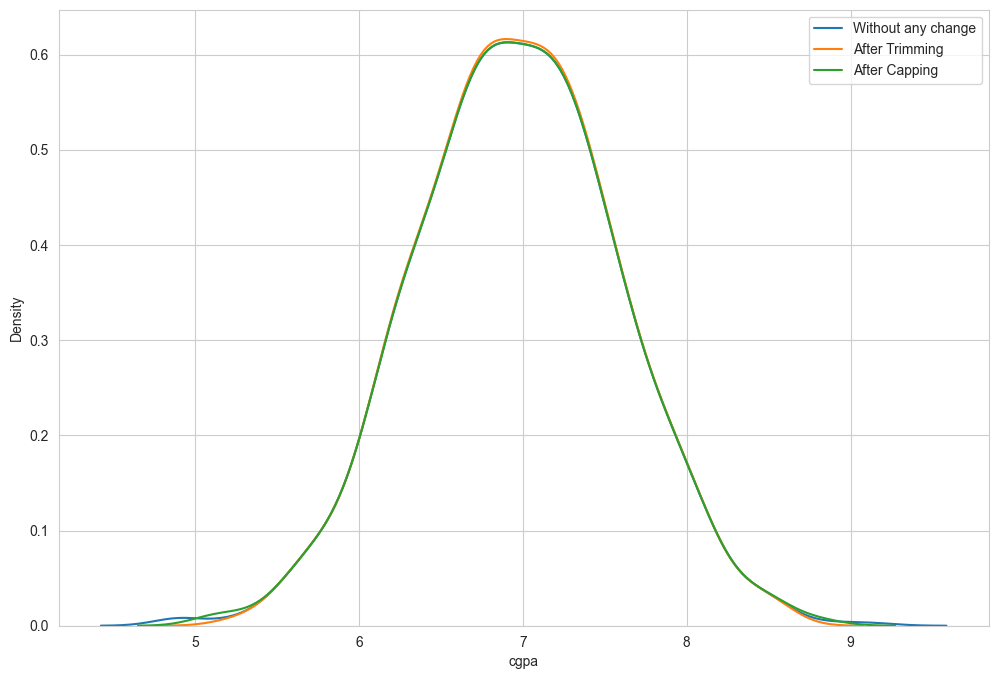

In [17]:
plt.figure(figsize=(12,8))
sns.kdeplot(data=df,x='cgpa', label="Without any change")
sns.kdeplot(data=df_trim,x='cgpa', label="After Trimming")
sns.kdeplot(data=df_cap,x='cgpa', label="After Capping")
plt.legend()